# MNIST

### MNIST 데이터 받기

In [1]:
import os
import sys
from six.moves import urllib
import gzip
import pickle
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt


SOURCE_URL = 'http://www.iro.umontreal.ca/~lisa/deep/data/mnist/mnist.pkl.gz'
FILENAME = SOURCE_URL.split('/')[-1]
DATA_DIR = './datasets'

def maybe_download(data_dir):
    filepath = os.path.join(data_dir, FILENAME)
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
    if not os.path.isfile(filepath):
        def _progress(count, block_size, total_size):
            sys.stdout.write('\r>> Downloading {} {:.1f} %'.format(
                FILENAME, float(count * block_size) / float(total_size) * 100.0))
            sys.stdout.flush()
        filepath, _ = urllib.request.urlretrieve(SOURCE_URL, filepath, _progress)
        print()
        statinfo = os.stat(filepath)
        print('Successfully donloaded', FILENAME, statinfo.st_size, 'bytes.')

def load(data_dir, subset='train'):
    maybe_download(data_dir)
    filepath = os.path.join(data_dir, FILENAME)
    
    f = gzip.open(filepath, 'rb')
    u = pickle._Unpickler(f)
    u.encoding = 'latin1'
    train_set, valid_set, test_set = u.load()
    f.close()
    
    if subset == 'train':
        trainx, trainy = train_set
        trainx = trainx.astype(np.float32).reshape(trainx.shape[0], 28, 28)
        trainy = trainy.astype(np.uint8)
        return trainx, trainy
    elif subset == 'test':
        testx, testy = test_set
        testx = testx.astype(np.float32).reshape(testx.shape[0], 28, 28)
        testy = testy.astype(np.uint8)
        return testx, testy
    elif subset== 'valid':
        validx, validy = valid_set
        validx = validx.astype(np.float32).reshape(validx.shape[0], 28, 28)
        validy = validy.astype(np.uint8)
        return validx, validy
    else:
        raise NotImplementedError('subset should be train or valid or test')

# Load data
train_data, train_label = load(DATA_DIR, 'train')
valid_data, valid_label = load(DATA_DIR, 'valid')
test_data, test_label = load(DATA_DIR, 'test')

# concatenate train and valid data as train data
train_data = np.concatenate((train_data, valid_data))
train_label = np.concatenate((train_label, valid_label))

### MNIST 데이터 확인 하기

In [2]:
# size of MNIST
print(train_data.shape)
print(train_label.shape)
print(test_data.shape)
print(test_label.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


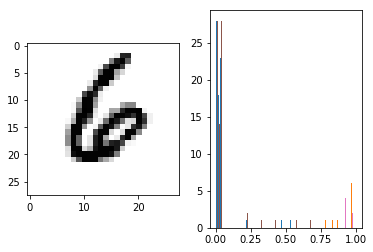

In [3]:
# show data
_, (ax1, ax2) = plt.subplots(1, 2)
sample_data = train_data[13]
ax1.imshow(sample_data, cmap=plt.cm.Greys);
ax2.hist(sample_data, bins=20, range=[0, 1]);

In [4]:
import tensorflow as tf
import random
import shutil

SUMMARY_DIR = './ResNet_summary'
TRAIN_DIR = SUMMARY_DIR + '/train'
TEST_DIR = SUMMARY_DIR + '/test'

if os.path.exists(SUMMARY_DIR):
    shutil.rmtree(SUMMARY_DIR)
if not os.path.exists(SUMMARY_DIR):
    os.makedirs(SUMMARY_DIR)
    os.makedirs(TRAIN_DIR)
    os.makedirs(TEST_DIR)

def get_next_batch(data, label, batch_size):
    n_data = data.shape[0]
    random_idx = random.sample(range(1, n_data), batch_size)
    
    batch_data = data[random_idx]
    batch_label = label[random_idx]
    return batch_data, batch_label

def get_one_hot(label):
    one_hot = np.zeros((label.shape[0], 10))
    one_hot[np.arange(label.shape[0]), label.astype(int)] = 1
    return one_hot

def fully_connected(inputs, out_channel, name='fc'):
    in_channel = inputs.get_shape().as_list()[1]
    w_shape = [in_channel, out_channel]
    b_shape = [out_channel]

    with tf.variable_scope(name):
        weights = tf.Variable(tf.truncated_normal(shape=w_shape, stddev=0.1), name='weights')
        biases = tf.Variable(tf.constant(0.1, shape=b_shape), name='biases')
        fc = tf.matmul(inputs, weights)
        fc = tf.nn.bias_add(fc, biases)

    return fc
    
def conv2d(inputs, filter_size, stride, out_channel, name='conv'):
    in_channel = inputs.get_shape().as_list()[3]
    w_shape = [filter_size, filter_size, in_channel, out_channel]
    b_shape = [out_channel]
    
    with tf.variable_scope(name):
        weights = tf.Variable(tf.truncated_normal(shape=w_shape, stddev=0.1), name='weights')
        biases = tf.Variable(tf.constant(0.1, shape=b_shape), name='biases')
        conv = tf.nn.conv2d(inputs, weights, strides=[1, stride, stride, 1], padding='SAME')
        conv = tf.nn.bias_add(conv, biases)
        
    return conv
    
def avg_pool_3x3(inputs):
    avg_pool = tf.nn.avg_pool(inputs, 
                              ksize=[1, 3, 3, 1], 
                              strides=[1, 2, 2, 1], 
                              padding='SAME', name='pool3x3')
    
    return avg_pool

def global_avg_pool(inputs):
    avg_pool = tf.reduce_mean(inputs, axis=[1, 2], name='glv_avg_pool')
    
    return avg_pool

def residual_block(inputs, output_channel, first_layer=False, name='resblk'):
    with tf.variable_scope(name):
        if first_layer:
            inputs_pool = avg_pool_3x3(inputs)
            identity = conv2d(inputs_pool, 1, 1, output_channel, name='pre_conv')
            conv1 = conv2d(inputs, 3, 2, output_channel, name='conv1')
        else:
            identity = inputs
            conv1 = conv2d(inputs, 3, 1, output_channel, name='conv1')
            
        conv1_relu = tf.nn.relu(conv1, name='conv1_relu')
        conv2 = conv2d(conv1_relu, 3, 1, output_channel, name='conv2')
        identity_mapping = tf.add(conv2, identity, name='identity_mapping')
        output = tf.nn.relu(identity_mapping, name='output_relu')
    return output
            
def get_cross_entropy_loss(y_true, y_hat, epsilon=1e-8):
    with tf.name_scope('cross_entropy'):
        cross_entropy = tf.reduce_mean(-tf.reduce_sum(y_true * tf.log(y_hat + epsilon), axis=[1]))
    return cross_entropy

def get_accuracy(y_true, y_hat):
    with tf.name_scope('accuracy'):
        correct_prediction = tf.equal(tf.argmax(y_hat, 1), tf.argmax(y_true, 1), name='correct_prediction')
        accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32), name='accuracy')
    return accuracy
            
learning_rate = 0.001
max_iter = 2000
batch_size = 100

train_label_hot = get_one_hot(train_label)
test_label_hot = get_one_hot(test_label)

x = tf.placeholder(tf.float32, [None, 28, 28], name='x')
y_true = tf.placeholder(tf.float32, [None, 10], name='y_true')
x_reshape = tf.reshape(x, [-1, 28, 28, 1], name='x_reshape')

with tf.name_scope('ResNet'):
    res1_1 = residual_block(x_reshape, 16, True, name='res1_1')
    res1_2 = residual_block(res1_1, 16, False, name='res1_2')
    res1_3 = residual_block(res1_2, 16, False, name='res1_3')

    res2_1 = residual_block(res1_3, 32, True, name='res2_1')
    res2_2 = residual_block(res2_1, 32, False, name='res2_2')
    res2_3 = residual_block(res2_2, 32, False, name='res2_3')

    res3_1 = residual_block(res2_3, 64, True, name='res3_1')
    res3_2 = residual_block(res3_1, 64, False, name='res3_2')
    res3_3 = residual_block(res3_2, 64, False, name='res3_3')

    glb_avg = global_avg_pool(res3_3)
    logit = fully_connected(glb_avg, 10, name='fc')
    y_hat = tf.nn.softmax(logit, name='y_hat')

cross_entropy = get_cross_entropy_loss(y_true, y_hat)
accuracy = get_accuracy(y_true, y_hat)
train_step = tf.train.AdamOptimizer(learning_rate).minimize(cross_entropy)

tf.summary.scalar('cross_entropy', cross_entropy)
tf.summary.scalar('accuracy', accuracy)
merged = tf.summary.merge_all()

init = tf.global_variables_initializer()

In [5]:
with tf.Session() as sess:
    train_writer = tf.summary.FileWriter(TRAIN_DIR, sess.graph)
    test_writer = tf.summary.FileWriter(TEST_DIR)
    
    sess.run(init)
    
    for step in range(max_iter):
        batch_x, batch_y = get_next_batch(train_data, train_label_hot, batch_size)
        _, loss, summary = sess.run([train_step, cross_entropy, merged], feed_dict={x: batch_x, y_true: batch_y})
        train_writer.add_summary(summary, step)
        acc, summary = sess.run([accuracy, merged], feed_dict={x: test_data, y_true: test_label_hot})
        test_writer.add_summary(summary, step)
        if (step + 1) % 10 == 0:
            print("{}th iteration, training loss: {:.4f}, test accuracy: {:.4f}".format(step + 1, loss, acc))

10th iteration, training loss: 2.2779, test accuracy: 0.2394
20th iteration, training loss: 2.2346, test accuracy: 0.1302
30th iteration, training loss: 2.0889, test accuracy: 0.3021
40th iteration, training loss: 1.8966, test accuracy: 0.4968
50th iteration, training loss: 1.4173, test accuracy: 0.5166
60th iteration, training loss: 1.0367, test accuracy: 0.6552
70th iteration, training loss: 0.7635, test accuracy: 0.7551
80th iteration, training loss: 0.8496, test accuracy: 0.7980
90th iteration, training loss: 0.5698, test accuracy: 0.8456
100th iteration, training loss: 0.4598, test accuracy: 0.8483
110th iteration, training loss: 0.2827, test accuracy: 0.8615
120th iteration, training loss: 0.3760, test accuracy: 0.8943
130th iteration, training loss: 0.4520, test accuracy: 0.8907
140th iteration, training loss: 0.3468, test accuracy: 0.9219
150th iteration, training loss: 0.3369, test accuracy: 0.9129
160th iteration, training loss: 0.2111, test accuracy: 0.9296
170th iteration, 

KeyboardInterrupt: 